<a href="https://colab.research.google.com/github/Dexter0013/Direct-Preference-Optimization-Case-Studies/blob/main/Model/%20DPO_Using_RF_DETR_and_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###STEP 1: INSTALLING LIBS

In [1]:
!pip install -q rfdetr supervision tqdm
!apt-get install -y ffmpeg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406.3/406.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 10.2 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


###1.1 LOAD DATASET

In [2]:
import os

os.makedirs('/content/ixmas', exist_ok=True)
!wget -q --show-progress -O /content/ixmas.zip \
  "https://documents.epfl.ch/groups/c/cv/cvlab-ixmas10/www/ixmas.zip"
!unzip -q /content/ixmas.zip -d /content/ixmas

/content/ixmas.zip  100%[===================>] 251.32M  24.0MB/s    in 15s     


###1.2 SET PATH

In [3]:
import glob
import json
import cv2
import numpy as np
from scipy.io import loadmat
from collections import defaultdict
from tqdm import tqdm
DATA_DIR = '/content/ixmas/ixmas'

###1.3 IXMAS Annotation Processing

In [4]:
import glob
from collections import defaultdict
from scipy.io import loadmat

def read_tag(mat_path):
    """Extract tag fields from a single .mat annotation file."""
    data = loadmat(mat_path)
    tag = data['tag'][0, 0]
    return {
        'avi': str(tag['avi'][0]) if tag['avi'].size else None,
        'actor': str(tag['actor'][0]) if tag['actor'].size else None,
        'cam': int(tag['cam'][0][0]),
        'start': int(tag['start'][0][0]),
        'stop': int(tag['stop'][0][0]),
        'action': int(tag['action'][0][0]) if tag['action'].size else None,
        'action_name': str(tag['action_name'][0]) if tag['action_name'].size else None,
        'actor_name': str(tag['actor_name'][0]) if tag['actor_name'].size else None,
        'name': int(tag['name'][0][0]),  # numeric id, not a string
    }

def build_single_view_streams(data_dir):
    """
    Groups data by individual camera streams per action instance.
    Filters to keep ONLY camera 3 streams (Step 1: Single fixed view).
    """
    mat_files = glob.glob(f"{data_dir}/**/*.mat", recursive=True)
    streams = {}

    for mat_path in mat_files:
        try:
            info = read_tag(mat_path)

            # --- FILTER LINE: Only process streams containing cam 3 ---
            if info['cam'] != 3:
                continue

            info['mat_path'] = mat_path
            info['avi_path'] = f"{data_dir}/{info['avi']}"

            # Create a unique key for this fixed camera stream
            stream_key = (info['actor_name'], info['action_name'], info['start'], info['stop'], info['cam'])
            info['instance_label'] = f"{info['actor_name']}_{info['action_name']}_{info['start']}_{info['stop']}_cam{info['cam']}"

            streams[stream_key] = info
        except Exception as e:
            print(f"Error parsing {mat_path}: {e}")

    print(f"Successfully processed {len(streams)} individual fixed-view streams from Camera 3.")
    return streams

# Initialize single fixed-view data streams (Camera 3 only)
single_view_streams = build_single_view_streams(DATA_DIR)

Successfully processed 360 individual fixed-view streams from Camera 3.


##1.4 Frame Extraction (FFmpeg)

In [5]:
import subprocess
import numpy as np

def extract_frames(avi_path, width=48, height=64):
    """Read raw BGR24 frames directly via ffmpeg pipe, bypassing cv2.VideoCapture
    entirely. Safe for IXMAS's uncompressed rawvideo AVI files."""
    frame_size = width * height * 3  # bgr24 = 3 bytes per pixel

    cmd = [
        'ffmpeg', '-loglevel', 'error',
        '-i', avi_path,
        '-f', 'rawvideo',
        '-pix_fmt', 'bgr24',
        '-'
    ]
    # Note: For long videos, capture_output=True fills RAM quickly.
    # Great for a test run on short IXMAS clips!
    result = subprocess.run(cmd, capture_output=True, timeout=30)
    raw_bytes = result.stdout

    if len(raw_bytes) == 0:
        print(f"No data read from {avi_path}: {result.stderr.decode()[:200]}")
        return []

    num_frames = len(raw_bytes) // frame_size
    frames = []
    for i in range(num_frames):
        chunk = raw_bytes[i*frame_size : (i+1)*frame_size]
        frame = np.frombuffer(chunk, dtype=np.uint8).reshape((height, width, 3))
        frames.append(frame)

    return frames

# --- Test code updated to use the filtered single_view_streams ---
if single_view_streams:
    # Grab the first available Camera 3 stream key
    sample_key = list(single_view_streams.keys())[0]
    test_path = single_view_streams[sample_key]['avi_path']

    print(f"Testing frame extraction on Camera 3 stream: {sample_key}")
    test_frames = extract_frames(test_path)
    print(f"Loaded {len(test_frames)} frames from {test_path}")

    if test_frames:
        print("Frame shape:", test_frames[0].shape, "dtype:", test_frames[0].dtype)
else:
    print("No Camera 3 streams found in your dataset directory. Check your DATA_DIR path.")

Testing frame extraction on Camera 3 stream: ('alba3', '07_walk', 523, 651, 3)
Loaded 129 frames from /content/ixmas/ixmas/alba3_07_walk_cam3_frames_0523_0651.avi
Frame shape: (64, 48, 3) dtype: uint8


###1.5 Frame Display and Verification

Loaded 129 frames
Frame shape: (64, 48, 3)


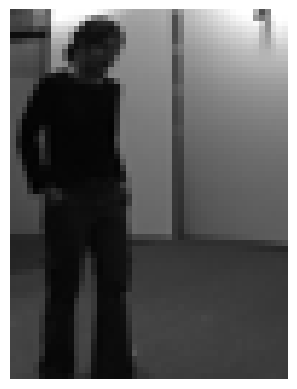

In [6]:
test_frames_swapped = extract_frames(test_path, width=48, height=64)
print(f"Loaded {len(test_frames_swapped)} frames")
if test_frames_swapped:
    print("Frame shape:", test_frames_swapped[0].shape)

import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(test_frames_swapped[0], cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

###1.6 Train Test Dataset Splitting

In [7]:
import random

def split_streams_train_val(single_view_streams, val_fraction=0.2, seed=42):
    keys = list(single_view_streams.keys())
    random.seed(seed)
    random.shuffle(keys)

    val_size = int(len(keys) * val_fraction)
    val_keys = set(keys[:val_size])
    train_keys = set(keys[val_size:])

    train_streams = {k: v for k, v in single_view_streams.items() if k in train_keys}
    val_streams = {k: v for k, v in single_view_streams.items() if k in val_keys}

    print(f"Total streams: {len(single_view_streams)}")
    print(f"Train streams: {len(train_streams)} ({len(train_streams)/len(single_view_streams):.1%})")
    print(f"Val streams:   {len(val_streams)} ({len(val_streams)/len(single_view_streams):.1%})")
    return train_streams, val_streams

train_streams, val_streams = split_streams_train_val(single_view_streams, val_fraction=0.2, seed=42)

Total streams: 360
Train streams: 288 (80.0%)
Val streams:   72 (20.0%)


###Step 2: Import the RDFETRNano Model for Object Detection Pipeline

In [8]:
from rfdetr import RFDETRNano

class RFDetrScorer:
    def __init__(self, threshold=0.3, person_class_id=1):
        self.model = RFDETRNano()
        self.threshold = threshold
        self.person_class_id = person_class_id

    def score(self, frame: np.ndarray) -> float:
        detections = self.model.predict(frame, threshold=self.threshold)
        if len(detections) == 0:
            return 0.0
        person_mask = detections.class_id == self.person_class_id
        if not person_mask.any():
            return 0.0
        return float(detections.confidence[person_mask].max())

detector = RFDetrScorer(threshold=0.3)
print("Detector ready.")

[2026-07-29 05:37:33] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-nano.pth


/usr/local/lib/python3.12/dist-packages/rfdetr/models/weights.py:258: FutureWarning: target=True is deprecated since `v0.8`; use `TargetMode.ARGS_REMAP` instead. Will be removed in `v1.0`.
  @deprecated(target=True, args_mapping={"train_config": None}, deprecated_in="1.7.0", remove_in="1.9.0", num_warns=-1)


/root/.roboflow/models/rf-detr-nano.pth:   0%|          | 0.00/349M [00:00<?, ?iB/s]

[2026-07-29 05:37:44] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-nano.pth


[2026-07-29 05:37:44] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-29 05:37:44] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-29 05:37:45] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-07-29 05:37:47] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-nano.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.


Detector ready.


In [10]:
score = detector.score(test_frames[0])
print(f"Detection confidence: {score}")

Detection confidence: 0.9326905012130737


##2.1 Temporal DPO Preference Pair Generation

In [10]:
import json
import os
from tqdm.notebook import tqdm

def build_preference_pairs_for_stream(stream_info, detector, window_size=8, stride=4):
    """
    Implements Steps 2, 3, 4, and 5 for a single fixed-view camera stream.
    Slices the video into overlapping 8-frame windows, scores them, and
    compares windows to form DPO preference pairs.
    """
    avi_path = stream_info['avi_path']
    frames = extract_frames(avi_path)

    if not frames:
        return []

    num_frames = len(frames)
    chunks = []

    # Steps 2 & 3: Cut video into short chunks (overlapping 8-frame windows)
    for start_idx in range(0, num_frames - window_size + 1, stride):
        end_idx = start_idx + window_size
        chunk_frames = frames[start_idx:end_idx]

        # Step 4: Run the real detector on each frame inside this chunk
        # We assign the max confidence found in the window as the chunk's score
        frame_scores = [detector.score(f) for f in chunk_frames]
        chunk_score = max(frame_scores) if frame_scores else 0.0

        chunks.append({
            'start_frame': start_idx,
            'end_frame': end_idx,
            'score': chunk_score
        })

    pairs = []
    # Step 5: Compare chunks in pairs ('this chunk was better than that one')
    # Loop through unique combinations of chunks within this single video stream
    for i in range(len(chunks)):
        for j in range(i + 1, len(chunks)):
            chunk_a = chunks[i]
            chunk_b = chunks[j]

            # Create a preference pair if there's a visible delta in confidence
            if abs(chunk_a['score'] - chunk_b['score']) > 0.05:
                if chunk_a['score'] > chunk_b['score']:
                    winner, loser = chunk_a, chunk_b
                else:
                    winner, loser = chunk_b, chunk_a

                pairs.append({
                    'instance': stream_info['instance_label'],
                    'avi_path': avi_path,
                    'winner_window': (winner['start_frame'], winner['end_frame']),
                    'loser_window': (loser['start_frame'], loser['end_frame']),
                    'winner_score': winner['score'],
                    'loser_score': loser['score']
                })
    return pairs

def build_all_preference_pairs(single_view_streams, detector, checkpoint_path="dpo_pairs_checkpoint.json", checkpoint_every=20):
    """
    Processes all Camera 3 streams, generates temporal preference pairs,
    and saves progress safely using checkpoints.
    """
    all_pairs, done_instances = [], set()

    # Load existing checkpoint if it exists
    if os.path.exists(checkpoint_path):
        try:
            with open(checkpoint_path, 'r') as f:
                ckpt = json.load(f)
            all_pairs = ckpt['pairs']
            done_instances = set(ckpt['done_instances'])
            print(f"Resumed: {len(all_pairs)} pairs, {len(done_instances)} streams done.")
        except Exception as e:
            print(f"Error loading checkpoint, starting fresh: {e}")
    else:
        print("No checkpoint found, starting fresh.")

    items = list(single_view_streams.items())

    for i, (key, stream_info) in enumerate(tqdm(items, desc="Processing Streams")):
        label = stream_info['instance_label']
        if label in done_instances:
            continue

        try:
            # Generate pairwise labels based on sequential window combinations
            pairs = build_preference_pairs_for_stream(stream_info, detector)
            all_pairs.extend(pairs)
            done_instances.add(label)
        except Exception as e:
            print(f"\nError processing stream {label}: {e}")
            continue

        # Periodic checkpoint backup
        if (i + 1) % checkpoint_every == 0:
            with open(checkpoint_path, 'w') as f:
                json.dump({'pairs': all_pairs, 'done_instances': list(done_instances)}, f)

    # Final save
    with open(checkpoint_path, 'w') as f:
        json.dump({'pairs': all_pairs, 'done_instances': list(done_instances)}, f)

    print(f"\nGenerated {len(all_pairs)} temporal DPO pairs across {len(done_instances)} video streams.")
    return all_pairs

train_pairs_raw = build_all_preference_pairs(train_streams, detector, checkpoint_path="dpo_train_pairs_checkpoint.json")
val_pairs_raw = build_all_preference_pairs(val_streams, detector, checkpoint_path="dpo_val_pairs_checkpoint.json")

Resumed: 2103 pairs, 288 streams done.


Processing Streams:   0%|          | 0/288 [00:00<?, ?it/s]


Generated 2508 temporal DPO pairs across 345 video streams.
Resumed: 411 pairs, 72 streams done.


Processing Streams:   0%|          | 0/72 [00:00<?, ?it/s]


Generated 804 temporal DPO pairs across 129 video streams.


##2.2 DINOv2 Embedder

In [11]:
import torch
import torch.nn as nn
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import numpy as np
import cv2

class DINOv2Embedder:
    """
    Wraps DINOv2-Small so it can be called as embedder(frame) -> 384-dim CLS embedding.
    Matches the calling convention used in get_window_embedding() from Stage 4.
    """
    def __init__(self, model_name="facebook/dinov2-small", device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.processor = AutoImageProcessor.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()  # frozen, no gradient updates

    def _to_pil(self, frame):
        """
        Converts a raw frame (numpy array, BGR from cv2 or RGB) into PIL Image
        expected by the HuggingFace processor.
        """
        if isinstance(frame, np.ndarray):
            # assume BGR from cv2/ffmpeg pipeline -> convert to RGB
            if frame.shape[-1] == 3:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            return Image.fromarray(frame)
        return frame  # already PIL

    def __call__(self, frame):
        """
        Takes a single raw frame, returns a 384-dim CLS token embedding as a torch tensor.
        """
        pil_img = self._to_pil(frame)
        inputs = self.processor(images=pil_img, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        # CLS token is the first token in the last hidden state
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # shape: (1, 384)
        return cls_embedding.squeeze(0)  # shape: (384,)


# --- Instantiate once, reuse across the whole pipeline ---
dinov2_embedder = DINOv2Embedder(model_name="facebook/dinov2-small")

print(f"DINOv2-Small loaded on {dinov2_embedder.device}")
print(f"Output embedding dim: {dinov2_embedder.model.config.hidden_size}")  # should print 384

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2-Small loaded on cuda
Output embedding dim: 384


##2.3 DPO Embedding Generation

In [24]:
import json
import os
import pickle
import numpy as np
import torch
from tqdm.notebook import tqdm

def get_window_embedding(frames, embedder, mode="mean"):
    """
    Converts a list of frames (a window) into a single fingerprint vector.
    mode='mean' -> average CLS embeddings across all frames in the window (temporal-aware)
    mode='last' -> embed only the most recent frame (cheaper, less context)
    """
    with torch.no_grad():
        if mode == "last":
            return embedder(frames[-1]).cpu().numpy()
        elif mode == "mean":
            embeds = [embedder(f).cpu().numpy() for f in frames]
            return np.mean(embeds, axis=0)


def build_embeddings_for_pairs(
    all_pairs,
    single_view_streams,
    embedder,
    mode="mean",
    checkpoint_path="dpo_embeddings_checkpoint.pkl",
    checkpoint_every=200
):
    """
    Stage 4: Converts each preference pair's winner/loser window into
    DINOv2 (or VideoMAE) embeddings, ready for DPO training in Stage 5.
    Caches embeddings per (avi_path, start_frame, end_frame) to avoid
    re-embedding the same window twice across different pairs.
    """
    embedded_pairs = []
    embedding_cache = {}
    start_idx = 0

    # Resume from checkpoint if it exists
    if os.path.exists(checkpoint_path):
        try:
            with open(checkpoint_path, 'rb') as f:
                ckpt = pickle.load(f)
            embedded_pairs = ckpt['embedded_pairs']
            embedding_cache = ckpt['embedding_cache']
            start_idx = ckpt['next_pair_idx']
            print(f"Resumed: {len(embedded_pairs)} pairs embedded, "
                  f"{len(embedding_cache)} unique windows cached, "
                  f"continuing from pair {start_idx}.")
        except Exception as e:
            print(f"Error loading checkpoint, starting fresh: {e}")
    else:
        print("No checkpoint found, starting fresh.")

    # Build a quick lookup so we don't re-extract full video frames every time
    frame_cache_by_video = {}

    def get_frames_cached(avi_path):
        if avi_path not in frame_cache_by_video:
            frame_cache_by_video[avi_path] = extract_frames(avi_path)
        return frame_cache_by_video[avi_path]

    def get_or_compute_embedding(avi_path, window):
        key = f"{avi_path}::{window[0]}-{window[1]}"
        if key in embedding_cache:
            return embedding_cache[key]

        frames = get_frames_cached(avi_path)
        window_frames = frames[window[0]:window[1]]
        emb = get_window_embedding(window_frames, embedder, mode=mode)
        embedding_cache[key] = emb
        return emb

    for i in tqdm(range(start_idx, len(all_pairs)), desc="Embedding pairs", initial=start_idx, total=len(all_pairs)):
        pair = all_pairs[i]
        avi_path = pair['avi_path']

        try:
            winner_emb = get_or_compute_embedding(avi_path, pair['winner_window'])
            loser_emb = get_or_compute_embedding(avi_path, pair['loser_window'])

            embedded_pairs.append({
                'instance': pair['instance'],
                'winner_embedding': winner_emb,
                'loser_embedding': loser_emb,
                'winner_score': pair['winner_score'],
                'loser_score': pair['loser_score']
            })
        except Exception as e:
            print(f"\nError embedding pair {i} ({avi_path}): {e}")
            continue

        # Periodic checkpoint backup
        if (i + 1) % checkpoint_every == 0:
            with open(checkpoint_path, 'wb') as f:
                pickle.dump({
                    'embedded_pairs': embedded_pairs,
                    'embedding_cache': embedding_cache,
                    'next_pair_idx': i + 1
                }, f)

        # Free memory for videos no longer needed (keep cache small)
        if len(frame_cache_by_video) > 3:
            oldest_key = next(iter(frame_cache_by_video))
            del frame_cache_by_video[oldest_key]

    # Final save
    with open(checkpoint_path, 'wb') as f:
        pickle.dump({
            'embedded_pairs': embedded_pairs,
            'embedding_cache': embedding_cache,
            'next_pair_idx': len(all_pairs)
        }, f)

    print(f"\nEmbedded {len(embedded_pairs)} pairs "
          f"({len(embedding_cache)} unique windows) -> saved to {checkpoint_path}")
    return embedded_pairs


##2.4 Train & Valid Set Embeddings

In [13]:
train_embedded_pairs = build_embeddings_for_pairs(
    train_pairs_raw, train_streams, embedder=dinov2_embedder, mode="mean",
    checkpoint_path="dpo_train_embeddings_checkpoint.pkl"
)

Resumed: 2103 pairs embedded, 927 unique windows cached, continuing from pair 2103.


Embedding pairs:  84%|########3 | 2103/2508 [00:00<?, ?it/s]


Embedded 2508 pairs (1115 unique windows) -> saved to dpo_train_embeddings_checkpoint.pkl


In [14]:
val_embedded_pairs = build_embeddings_for_pairs(
    val_pairs_raw, val_streams, embedder=dinov2_embedder, mode="mean",
    checkpoint_path="dpo_val_embeddings_checkpoint.pkl"
)

Resumed: 411 pairs embedded, 194 unique windows cached, continuing from pair 411.


Embedding pairs:  51%|#####1    | 411/804 [00:00<?, ?it/s]


Embedded 804 pairs (434 unique windows) -> saved to dpo_val_embeddings_checkpoint.pkl


##2.5 DPO Policy Training Setup

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from tqdm.notebook import tqdm

# --- Policy architecture ---
class WindowSelectorPolicy(nn.Module):
    def __init__(self, dim=384, hidden=256, heads=4, ff=512, layers=2):
        super().__init__()
        self.proj = nn.Linear(dim, hidden)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=heads, dim_feedforward=ff, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers)
        self.score_head = nn.Linear(hidden, 1)

    def forward(self, x):
        # x: (batch, dim) -> add fake seq_len=1 for TransformerEncoder
        x = self.proj(x).unsqueeze(1)          # (batch, 1, hidden)
        x = self.encoder(x)                     # (batch, 1, hidden)
        x = x.squeeze(1)                         # (batch, hidden)
        return self.score_head(x).squeeze(-1)    # (batch,)


# --- Dataset wrapping your embedded pairs ---
class PreferencePairDataset(Dataset):
    def __init__(self, embedded_pairs):
        self.pairs = embedded_pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        winner = torch.as_tensor(pair['winner_embedding'], dtype=torch.float32)
        loser = torch.as_tensor(pair['loser_embedding'], dtype=torch.float32)
        return winner, loser


# --- DPO loss ---
def dpo_loss(policy, winner_emb, loser_emb, beta=0.5):
    logp_winner = policy(winner_emb)
    logp_loser = policy(loser_emb)
    # reference policy is implicit uniform -> cancels out, so this reduces to:
    loss = -F.logsigmoid(beta * (logp_winner - logp_loser))
    return loss.mean()


# --- Training loop ---
def train_dpo_policy(
    embedded_pairs,
    epochs=20,
    batch_size=64,
    lr=1e-4,
    beta=0.5,
    checkpoint_path="dpo_policy.pt",
    device=None
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    dataset = PreferencePairDataset(embedded_pairs)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    policy = WindowSelectorPolicy().to(device)
    optimizer = torch.optim.AdamW(policy.parameters(), lr=lr)

    history = []

    for epoch in range(epochs):
        policy.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for winner_emb, loser_emb in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            winner_emb = winner_emb.to(device)
            loser_emb = loser_emb.to(device)

            loss = dpo_loss(policy, winner_emb, loser_emb, beta=beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            # accuracy: how often policy correctly ranks winner > loser
            with torch.no_grad():
                logp_w = policy(winner_emb)
                logp_l = policy(loser_emb)
                correct += (logp_w > logp_l).sum().item()
                total += winner_emb.size(0)

        avg_loss = epoch_loss / len(dataloader)
        accuracy = correct / total
        history.append({'epoch': epoch + 1, 'loss': avg_loss, 'accuracy': accuracy})
        print(f"Epoch {epoch+1}/{epochs} — loss: {avg_loss:.4f} — pairwise accuracy: {accuracy:.4f}")

        # checkpoint every epoch
        torch.save(policy.state_dict(), checkpoint_path)

    print(f"\nTraining complete. Final policy saved to {checkpoint_path}")
    return policy, history



In [ ]:
policy, history = train_dpo_policy(
    train_embedded_pairs,
    epochs=20, batch_size=64, lr=1e-4, beta=0.5,
    checkpoint_path="dpo_policy_clean.pt"
)

Epoch 1/20:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/20 — loss: 0.3203 — pairwise accuracy: 0.9033


Epoch 2/20:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2/20 — loss: 0.1290 — pairwise accuracy: 0.9639


Epoch 3/20:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 18/20 — loss: 0.0120 — pairwise accuracy: 0.9980


Epoch 19/20:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 19/20 — loss: 0.0126 — pairwise accuracy: 0.9985


Epoch 20/20:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 20/20 — loss: 0.0142 — pairwise accuracy: 0.9976

Training complete. Final policy saved to dpo_policy_clean.pt


## Load the .pkl and .json files if present

In [13]:
import json
import pickle

# Preference pairs (raw, pre-embedding)
with open("dpo_train_pairs_checkpoint.json", "r") as f:
    train_pairs_raw = json.load(f)['pairs']

with open("dpo_val_pairs_checkpoint.json", "r") as f:
    val_pairs_raw = json.load(f)['pairs']

# Embedded pairs (post-DINOv2)
with open("dpo_train_embeddings_checkpoint.pkl", "rb") as f:
    train_embedded_pairs = pickle.load(f)['embedded_pairs']

with open("dpo_val_embeddings_checkpoint.pkl", "rb") as f:
    val_embedded_pairs = pickle.load(f)['embedded_pairs']

print(f"Train pairs (raw): {len(train_pairs_raw)} | Val pairs (raw): {len(val_pairs_raw)}")
print(f"Train pairs (embedded): {len(train_embedded_pairs)} | Val pairs (embedded): {len(val_embedded_pairs)}")

Train pairs (raw): 2103 | Val pairs (raw): 411
Train pairs (embedded): 2103 | Val pairs (embedded): 411


## Policy Evaluation

In [16]:
def evaluate_policy(policy, val_pairs, device, batch_size=64):
    policy.eval()
    policy.to(device) # Ensure the policy model is on the correct device
    dataset = PreferencePairDataset(val_pairs)
    dataloader = DataLoader(dataset, batch_size=batch_size)

    correct, total = 0, 0
    with torch.no_grad():
        for winner_emb, loser_emb in dataloader:
            winner_emb, loser_emb = winner_emb.to(device), loser_emb.to(device)
            logp_w = policy(winner_emb)
            logp_l = policy(loser_emb)
            correct += (logp_w > logp_l).sum().item()
            total += winner_emb.size(0)
    return correct / total

val_accuracy = evaluate_policy(policy, val_embedded_pairs, device="cuda" if torch.cuda.is_available() else "cpu")
print(f"Validation pairwise accuracy: {val_accuracy:.4f}")

Validation pairwise accuracy: 1.0000


##2.6 Arcitecture of the DPO policy for frame selection

In [15]:
policy = WindowSelectorPolicy()
policy.load_state_dict(torch.load("dpo_policy_clean.pt"))
policy.eval()

WindowSelectorPolicy(
  (proj): Linear(in_features=384, out_features=256, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (score_head): Linear(in_features=256, out_features=1, bias=True)
)

##2.7 Validation Scores

In [17]:
import numpy as np
import torch

def precision_recall_at_threshold(winner_scores, loser_scores, threshold):
    tp = np.sum(np.array(winner_scores) > threshold)  # True Positives: winner score > threshold
    fn = np.sum(np.array(winner_scores) <= threshold) # False Negatives: winner score <= threshold
    fp = np.sum(np.array(loser_scores) > threshold)   # False Positives: loser score > threshold
    tn = np.sum(np.array(loser_scores) <= threshold)  # True Negatives: loser score <= threshold

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    counts = {'TP': int(tp), 'FN': int(fn), 'FP': int(fp), 'TN': int(tn)}
    return precision, recall, counts

def find_best_threshold(winner_scores, loser_scores, num_steps=100):
    all_scores = np.concatenate([winner_scores, loser_scores])
    min_score = np.min(all_scores)
    max_score = np.max(all_scores)

    best_accuracy = -1
    best_threshold = None

    for thresh in np.linspace(min_score, max_score, num_steps):
        tp = np.sum(np.array(winner_scores) > thresh)
        fn = np.sum(np.array(winner_scores) <= thresh)
        fp = np.sum(np.array(loser_scores) > thresh)
        tn = np.sum(np.array(loser_scores) <= thresh)

        total_samples = tp + fn + fp + tn
        if total_samples > 0:
            accuracy = (tp + tn) / total_samples
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_threshold = thresh

    return best_threshold, best_accuracy

device = "cuda" if torch.cuda.is_available() else "cpu"
policy.to(device)

with torch.no_grad():
    winner_scores_full = [policy(torch.as_tensor(p['winner_embedding']).float().unsqueeze(0).to(device)).item() for p in val_embedded_pairs]
    loser_scores_full = [policy(torch.as_tensor(p['loser_embedding']).float().unsqueeze(0).to(device)).item() for p in val_embedded_pairs]

print(f"Val set size: {len(val_embedded_pairs)} pairs")
print(f"Winner scores: mean={np.mean(winner_scores_full):.3f}, min={min(winner_scores_full):.3f}, max={max(winner_scores_full):.3f}")
print(f"Loser scores:  mean={np.mean(loser_scores_full):.3f}, min={min(loser_scores_full):.3f}, max={max(loser_scores_full):.3f}")

best_thresh, best_acc = find_best_threshold(winner_scores_full, loser_scores_full)
print(f"\nBest threshold: {best_thresh:.3f} — Accuracy: {best_acc:.3f}")

precision, recall, counts = precision_recall_at_threshold(winner_scores_full, loser_scores_full, best_thresh)
print(f"Precision: {precision:.3f} | Recall: {recall:.3f}")
print(counts)

Val set size: 411 pairs
Winner scores: mean=11.816, min=-1.497, max=13.202
Loser scores:  mean=-3.560, min=-10.553, max=10.354

Best threshold: 5.044 — Accuracy: 0.953
Precision: 0.951 | Recall: 0.954
{'TP': 392, 'FN': 19, 'FP': 20, 'TN': 391}


##2.8 Inference Processing Engine

In [18]:
import cv2
import torch
import numpy as np
import json
import os
from collections import deque
from tqdm.notebook import tqdm

THRESHOLD = 5.09
device = "cuda" if torch.cuda.is_available() else "cpu"
policy.to(device)
policy.eval()


def process_local_video_chunked(
    video_path,
    policy,
    detector,
    embedder,
    window_size=8,
    stride=4,
    threshold=THRESHOLD,
    output_json=None
):
    frames = extract_frames(video_path)
    num_frames = len(frames)

    results = []
    last_score = None  # carry-forward detection confidence, not full bbox (until detector interface confirmed)

    for start_idx in range(0, num_frames - window_size + 1, stride):
        end_idx = start_idx + window_size
        window_frames = frames[start_idx:end_idx]

        embedding = get_window_embedding(window_frames, embedder, mode="mean")
        embedding_tensor = torch.as_tensor(embedding, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            policy_score = policy(embedding_tensor).item()

        detection_score = last_score
        ran_detector = policy_score > threshold

        if ran_detector:
            detection_score = detector.score(window_frames[-1])  # confirmed method from Stage 3
            last_score = detection_score

        results.append({
            "start_frame": start_idx,
            "end_frame": end_idx,
            "policy_score": policy_score,
            "ran_detector": ran_detector,
            "detection_score": detection_score
        })

    if output_json:
        with open(output_json, "w") as f:
            json.dump(results, f, indent=2)

    return results


def process_all_streams(single_view_streams, policy, detector, embedder, output_dir="stage6_results", threshold=THRESHOLD):
    os.makedirs(output_dir, exist_ok=True)
    all_results = {}

    for key, stream_info in tqdm(single_view_streams.items(), desc="Stage 6 - Processing streams"):
        label = stream_info['instance_label']
        avi_path = stream_info['avi_path']
        output_json = os.path.join(output_dir, f"{label}.json")

        try:
            results = process_local_video_chunked(
                avi_path, policy, detector, embedder,
                threshold=threshold, output_json=output_json
            )
            all_results[label] = results
        except Exception as e:
            print(f"Error processing {label}: {e}")
            continue

    total_windows = sum(len(r) for r in all_results.values())
    detector_calls = sum(sum(w["ran_detector"] for w in r) for r in all_results.values())
    print(f"\nProcessed {len(all_results)} streams, {total_windows} windows total.")
    if total_windows > 0:
        print(f"Detector ran on {detector_calls}/{total_windows} windows ({detector_calls/total_windows:.1%})")
        print(f"Compute saved: {1 - detector_calls/total_windows:.1%} of windows skipped detection")

    return all_results

##2.9 Sanity Check

In [ ]:
import itertools

THRESHOLD = 5.09

# Grab just 2 streams to test on
sample_streams = dict(itertools.islice(single_view_streams.items(), 20))
print(f"Testing on: {[v['instance_label'] for v in sample_streams.values()]}")

sanity_results = process_all_streams(
    sample_streams,
    policy,
    detector,
    dinov2_embedder,
    output_dir="stage6_sanity_check101"
)

Testing on: ['clare2_02_cross-arms_124_200_cam3', 'alba1_11_point_872_967_cam3', 'clare1_12_pick-up_1737_1809_cam3', 'amel2_07_walk_556_683_cam3', 'julien3_12_pick-up_965_1016_cam3', 'nicolas2_05_get-up_335_427_cam3', 'chiara1_07_walk_520_668_cam3', 'amel3_07_walk_642_780_cam3', 'andreas2_01_check-watch_43_107_cam3', 'florian1_05_get-up_353_412_cam3', 'hedlena2_09_punch_765_814_cam3', 'amel1_02_cross-arms_139_211_cam3', 'julien3_10_kick_826_897_cam3', 'andreas1_05_get-up_404_491_cam3', 'amel3_10_kick_893_961_cam3', 'andreas3_11_point_884_940_cam3', 'amel3_05_get-up_486_548_cam3', 'daniel3_11_point_795_836_cam3', 'nicolas3_12_pick-up_1034_1098_cam3', 'andreas2_08_wave_729_788_cam3']


Stage 6 - Processing streams:   0%|          | 0/20 [00:00<?, ?it/s]


Processed 20 streams, 368 windows total.
Detector ran on 276/368 windows (75.0%)
Compute saved: 25.0% of windows skipped detection


##Step 3: Specific Extractor for MP4 Video

In [19]:
def process_local_video_chunked(
    video_path, policy, detector, embedder,
    window_size=8, stride=4, threshold=THRESHOLD, output_json=None,
    use_generic_extractor=True
):
    if use_generic_extractor:
        frames = extract_frames_generic(video_path)
    else:
        frames = extract_frames(video_path)

    num_frames = len(frames)
    results = []
    last_score = None

    for start_idx in range(0, num_frames - window_size + 1, stride):
        end_idx = start_idx + window_size
        window_frames = frames[start_idx:end_idx]

        embedding = get_window_embedding(window_frames, embedder, mode="mean")
        embedding_tensor = torch.as_tensor(embedding, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            policy_score = policy(embedding_tensor).item()

        detection_score = last_score
        ran_detector = policy_score > threshold

        if ran_detector:
            detection_score = detector.score(window_frames[-1])
            last_score = detection_score

        results.append({
            "start_frame": start_idx,
            "end_frame": end_idx,
            "policy_score": policy_score,
            "ran_detector": ran_detector,
            "detection_score": detection_score
        })

    if output_json:
        with open(output_json, "w") as f:
            json.dump(results, f, indent=2)

    return results

In [20]:
import json
import time
import numpy as np
import torch
from collections import Counter
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt

device = device if 'device' in dir() else ("cuda" if torch.cuda.is_available() else "cpu")
policy.to(device)
policy.eval()


WindowSelectorPolicy(
  (proj): Linear(in_features=384, out_features=256, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (score_head): Linear(in_features=256, out_features=1, bias=True)
)

##3.1 Download ucf101 Dataset

In [21]:
!pip install huggingface_hub -q
from huggingface_hub import hf_hub_download
import tarfile

# Download the archive
tar_path = hf_hub_download(
    repo_id="sayakpaul/ucf101-subset",
    filename="UCF101_subset.tar.gz",
    repo_type="dataset"
)

# Extract it
with tarfile.open(tar_path) as tar:
    tar.extractall("/content/ucf101_subset")

print("Extracted to /content/ucf101_subset")

UCF101_subset.tar.gz: reconstructing file:   0%|          |  0.00B /  171MB            

UCF101_subset.tar.gz: downloading bytes:           |  0.00B            

Extracted to /content/ucf101_subset


##3.2 Annotated Output Video with Bounding Boxes

In [51]:
import cv2
import time
import subprocess
import numpy as np
import supervision as sv
from IPython.display import HTML
from base64 import b64encode

THRESHOLD = 5.09

def process_and_annotate_video_with_boxes(
    video_path, policy, detector, embedder,
    window_size=8, stride=4, threshold=THRESHOLD,
    output_video_path="annotated_output.mp4",
    model_input_size=(64, 48),
    det_threshold=0.5
):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    frames_full = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames_full.append(frame)
    cap.release()

    num_frames = len(frames_full)
    if num_frames == 0:
        raise ValueError(f"No frames read from {video_path}")

    frames_small = [cv2.resize(f, model_input_size) for f in frames_full]
    scale_x = frames_full[0].shape[1] / model_input_size[0]
    scale_y = frames_full[0].shape[0] / model_input_size[1]

    h, w = frames_full[0].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

    results = []
    last_score, last_boxes = None, np.empty((0, 4))
    decision_per_frame = ["SKIP"] * num_frames
    boxes_per_frame = [np.empty((0, 4)) for _ in range(num_frames)]

    for start_idx in range(0, num_frames - window_size + 1, stride):
        end_idx = start_idx + window_size
        window_frames = frames_small[start_idx:end_idx]

        embedding = get_window_embedding(window_frames, embedder, mode="mean")
        embedding_tensor = torch.as_tensor(embedding, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            policy_score = policy(embedding_tensor).item()

        ran_detector = policy_score > threshold
        detection_score = last_score
        boxes = last_boxes

        if ran_detector:
            rgb_frame = cv2.cvtColor(window_frames[-1], cv2.COLOR_BGR2RGB)
            detections = detector.model.predict(rgb_frame, threshold=det_threshold)

            if hasattr(detector, "person_class_id") and detector.person_class_id is not None:
                mask = detections.class_id == detector.person_class_id
                boxes = detections.xyxy[mask]
                confidences = detections.confidence[mask]
            else:
                boxes = detections.xyxy
                confidences = detections.confidence

            detection_score = float(confidences.max()) if len(confidences) > 0 else 0.0
            last_score, last_boxes = detection_score, boxes

        label = "DETECT" if ran_detector else "SKIP"
        for i in range(start_idx, min(end_idx, num_frames)):
            decision_per_frame[i] = f"{label} (score={policy_score:.2f})"
            boxes_per_frame[i] = boxes

        results.append({
            "start_frame": start_idx, "end_frame": end_idx,
            "policy_score": policy_score, "ran_detector": ran_detector,
            "detection_score": detection_score
        })

    for i, frame in enumerate(frames_full):
        annotated = frame.copy()
        color = (0, 200, 0) if "DETECT" in decision_per_frame[i] else (0, 0, 200)
        cv2.putText(annotated, decision_per_frame[i], (15, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)

        for box in boxes_per_frame[i]:
            x1, y1, x2, y2 = box
            x1, x2 = int(x1 * scale_x), int(x2 * scale_x)
            y1, y2 = int(y1 * scale_y), int(y2 * scale_y)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (255, 200, 0), 2)

        writer.write(annotated)

    writer.release()

    # --- Re-encode to browser-playable H.264, works regardless of input format ---
    fixed_path = output_video_path.replace(".mp4", "_fixed.mp4")
    subprocess.run([
        "ffmpeg", "-y", "-i", output_video_path,
        "-vcodec", "libx264", "-pix_fmt", "yuv420p",
        fixed_path
    ], capture_output=True)

    return results, fixed_path


start = time.time()
results, out_path = process_and_annotate_video_with_boxes(
    "/content/Video.mp4",
    policy, detector, dinov2_embedder,
    threshold=THRESHOLD, output_video_path="baby103_boxes.mp4"
)
print(f"Total time: {time.time()-start:.2f}s")

scores = [w["policy_score"] for w in results]
ran = sum(w["ran_detector"] for w in results)
total = len(results)
print(f"Detector ran on: {ran}/{total} ({ran/total:.1%})")
print(f"Compute saved: {1 - ran/total:.1%}")

mp4 = open(out_path, 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=500 controls><source src="{data_url}" type="video/mp4"></video>')

Total time: 65.25s
Detector ran on: 178/352 (50.6%)
Compute saved: 49.4%


## Step 4: Benchmarking & Evaluation Metrics (IXMAS)

In [36]:
import json
import time
import numpy as np
import torch
from collections import Counter
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt

device = device if 'device' in dir() else ("cuda" if torch.cuda.is_available() else "cpu")
policy.to(device)
policy.eval()


WindowSelectorPolicy(
  (proj): Linear(in_features=384, out_features=256, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (score_head): Linear(in_features=256, out_features=1, bias=True)
)

##4.1 Ranking Quality: Pairwise Accuracy, ROC-AUC, PR-AUC

In [37]:
def get_scores(policy, pairs, device, batch_size=256):
    """Returns (winner_scores, loser_scores) as numpy arrays for a list of embedded pairs."""
    policy.eval()
    winner_scores, loser_scores = [], []
    with torch.no_grad():
        for i in range(0, len(pairs), batch_size):
            batch = pairs[i:i+batch_size]
            w = torch.stack([torch.as_tensor(p['winner_embedding'], dtype=torch.float32) for p in batch]).to(device)
            l = torch.stack([torch.as_tensor(p['loser_embedding'], dtype=torch.float32) for p in batch]).to(device)
            winner_scores.append(policy(w).cpu().numpy())
            loser_scores.append(policy(l).cpu().numpy())
    return np.concatenate(winner_scores), np.concatenate(loser_scores)


def ranking_metrics(policy, pairs, device, label=""):
    winner_scores, loser_scores = get_scores(policy, pairs, device)
    margins = winner_scores - loser_scores

    labels = np.concatenate([np.ones_like(winner_scores), np.zeros_like(loser_scores)])
    scores = np.concatenate([winner_scores, loser_scores])

    metrics = {
        "n_pairs": len(pairs),
        "pairwise_accuracy": float(np.mean(margins > 0)),
        "roc_auc": float(roc_auc_score(labels, scores)),
        "pr_auc": float(average_precision_score(labels, scores)),
        "margin_mean": float(margins.mean()),
        "margin_std": float(margins.std()),
        "margin_p10": float(np.percentile(margins, 10)),   # worst-case separation
        "winner_score_mean": float(winner_scores.mean()),
        "loser_score_mean": float(loser_scores.mean()),
    }
    print(f"--- {label} (n={metrics['n_pairs']}) ---")
    for k, v in metrics.items():
        if k != "n_pairs":
            print(f"  {k:20s}: {v:.4f}")
    return metrics, winner_scores, loser_scores


train_metrics, train_w, train_l = ranking_metrics(policy, train_embedded_pairs, device, "TRAIN")
val_metrics, val_w, val_l       = ranking_metrics(policy, val_embedded_pairs, device, "VAL")

overfit_gap = train_metrics["pairwise_accuracy"] - val_metrics["pairwise_accuracy"]
print(f"\nTrain/val accuracy gap: {overfit_gap:+.4f} "
      f"({'watch for overfitting' if overfit_gap > 0.07 else 'looks fine'})")

--- TRAIN (n=2103) ---
  pairwise_accuracy   : 0.9919
  roc_auc             : 0.9562
  pr_auc              : 0.9672
  margin_mean         : 14.5286
  margin_std          : 6.2054
  margin_p10          : 6.8843
  winner_score_mean   : 10.4110
  loser_score_mean    : -4.1176
--- VAL (n=411) ---
  pairwise_accuracy   : 1.0000
  roc_auc             : 0.9905
  pr_auc              : 0.9915
  margin_mean         : 15.3758
  margin_std          : 4.6984
  margin_p10          : 9.3976
  winner_score_mean   : 11.8162
  loser_score_mean    : -3.5596

Train/val accuracy gap: -0.0081 (looks fine)


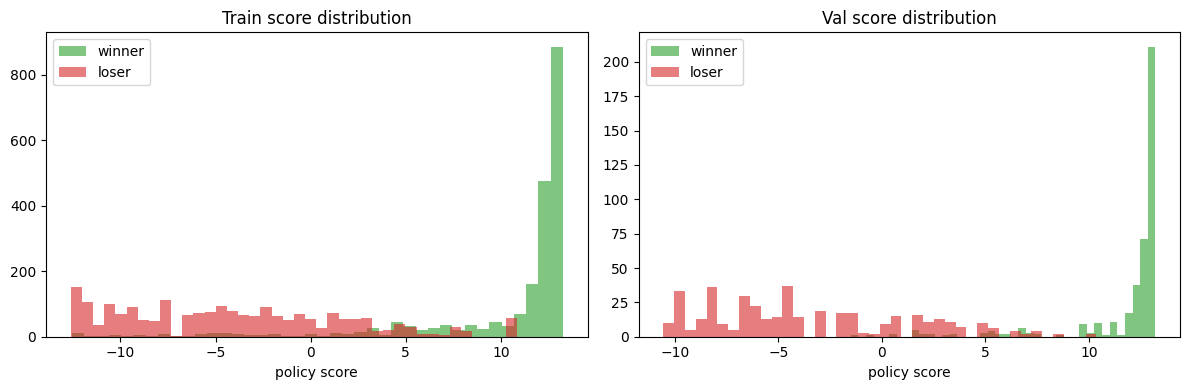

In [38]:
# Score separation histogram - visually, are winner/loser distributions actually distinct
# or mostly overlapping (which would explain a mediocre AUC even with 'ok' accuracy)?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (w, l, title) in zip(axes, [(train_w, train_l, "Train"), (val_w, val_l, "Val")]):
    ax.hist(w, bins=40, alpha=0.6, label="winner", color="tab:green")
    ax.hist(l, bins=40, alpha=0.6, label="loser", color="tab:red")
    ax.set_title(f"{title} score distribution")
    ax.set_xlabel("policy score")
    ax.legend()
plt.tight_layout()
plt.savefig("stage7_score_distributions.png", dpi=120)
plt.show()


## 4.2 Full Threshold Sweep: Precision / Recall / F1 vs Compute-Savings

In [39]:
def threshold_sweep(winner_scores, loser_scores, num_steps=300):
    all_scores = np.concatenate([winner_scores, loser_scores])
    thresholds = np.linspace(all_scores.min(), all_scores.max(), num_steps)

    rows = []
    for t in thresholds:
        tp = int(np.sum(winner_scores > t))
        fn = int(np.sum(winner_scores <= t))
        fp = int(np.sum(loser_scores > t))
        tn = int(np.sum(loser_scores <= t))
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        accuracy = (tp + tn) / (tp + fn + fp + tn)
        call_rate = (tp + fp) / (tp + fn + fp + tn)  # fraction of windows that would trigger the detector
        rows.append({"threshold": t, "precision": precision, "recall": recall, "f1": f1,
                     "accuracy": accuracy, "call_rate": call_rate})
    return rows


sweep = threshold_sweep(val_w, val_l)
best_acc_row = max(sweep, key=lambda r: r["accuracy"])
best_f1_row = max(sweep, key=lambda r: r["f1"])

print(f"Best-accuracy threshold : {best_acc_row['threshold']:.3f}  "
      f"(acc={best_acc_row['accuracy']:.3f}, precision={best_acc_row['precision']:.3f}, "
      f"recall={best_acc_row['recall']:.3f}, call_rate={best_acc_row['call_rate']:.1%})")
print(f"Best-F1 threshold       : {best_f1_row['threshold']:.3f}  "
      f"(f1={best_f1_row['f1']:.3f}, precision={best_f1_row['precision']:.3f}, "
      f"recall={best_f1_row['recall']:.3f}, call_rate={best_f1_row['call_rate']:.1%})")

# Check where the hardcoded thresholds from the notebook actually sit
for hardcoded in [10.868, 10.21]:
    closest = min(sweep, key=lambda r: abs(r["threshold"] - hardcoded))
    print(f"\nHardcoded THRESHOLD={hardcoded} -> closest sweep point t={closest['threshold']:.3f}: "
          f"precision={closest['precision']:.3f}, recall={closest['recall']:.3f}, "
          f"call_rate={closest['call_rate']:.1%}")


Best-accuracy threshold : 5.098  (acc=0.953, precision=0.951, recall=0.954, call_rate=50.1%)
Best-F1 threshold       : 5.098  (f1=0.953, precision=0.951, recall=0.954, call_rate=50.1%)

Hardcoded THRESHOLD=10.868 -> closest sweep point t=10.898: precision=1.000, recall=0.849, call_rate=42.5%

Hardcoded THRESHOLD=10.21 -> closest sweep point t=10.183: precision=0.994, recall=0.876, call_rate=44.0%


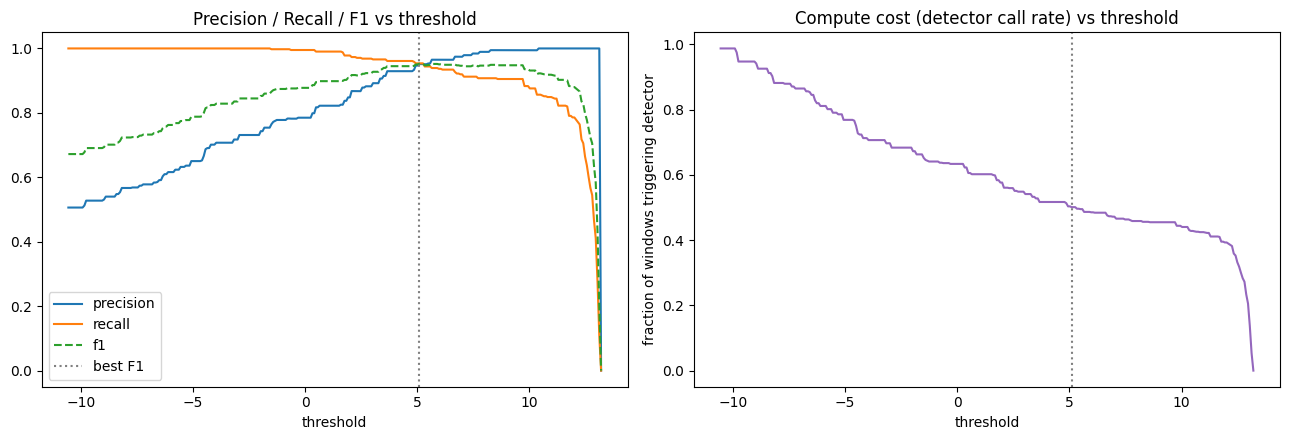

Confusion matrix at t=5.098 (rows=actual [loser,winner], cols=predicted [below,above]):
[[391  20]
 [ 19 392]]


In [40]:
# Precision/Recall/F1 and call-rate curves vs threshold
ts = [r["threshold"] for r in sweep]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ts, [r["precision"] for r in sweep], label="precision")
axes[0].plot(ts, [r["recall"] for r in sweep], label="recall")
axes[0].plot(ts, [r["f1"] for r in sweep], label="f1", linestyle="--")
axes[0].axvline(best_f1_row["threshold"], color="gray", linestyle=":", label="best F1")
axes[0].set_xlabel("threshold"); axes[0].set_title("Precision / Recall / F1 vs threshold"); axes[0].legend()

axes[1].plot(ts, [r["call_rate"] for r in sweep], color="tab:purple")
axes[1].axvline(best_f1_row["threshold"], color="gray", linestyle=":")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("fraction of windows triggering detector")
axes[1].set_title("Compute cost (detector call rate) vs threshold")

plt.tight_layout()
plt.savefig("stage7_threshold_sweep.png", dpi=120)
plt.show()

# Confusion matrix at the best-F1 threshold
t_star = best_f1_row["threshold"]
labels = np.concatenate([np.ones_like(val_w), np.zeros_like(val_l)])
preds = (np.concatenate([val_w, val_l]) > t_star).astype(int)
cm = confusion_matrix(labels, preds)
print(f"Confusion matrix at t={t_star:.3f} (rows=actual [loser,winner], cols=predicted [below,above]):")
print(cm)


## 4.3 Compute-Efficiency Benchmark

In [41]:
def build_ground_truth(streams_subset, detector, window_size=8, stride=4):
    """Runs the real detector on every window (expensive - only for a small benchmark subset)."""
    gt = {}
    for key, stream_info in streams_subset.items():
        avi_path = stream_info['avi_path']
        frames = extract_frames(avi_path)
        num_frames = len(frames)
        window_scores = []
        for start_idx in range(0, num_frames - window_size + 1, stride):
            end_idx = start_idx + window_size
            chunk = frames[start_idx:end_idx]
            frame_scores = [detector.score(f) for f in chunk]
            window_scores.append(max(frame_scores) if frame_scores else 0.0)
        gt[key] = {"stream_info": stream_info, "window_scores": window_scores}
    return gt


def evaluate_gating_methods(gt, policy, embedder, device, window_size=8, stride=4):
    """For each stream, compares DPO-policy top-k, random top-k, and uniform-stride top-k
    against the ground-truth top-k windows (by true detector score), at matched budget k."""
    results = {"dpo_policy": [], "random": [], "uniform_stride": []}

    for key, entry in gt.items():
        avi_path = entry["stream_info"]["avi_path"]
        window_scores = np.array(entry["window_scores"])
        n_windows = len(window_scores)
        if n_windows < 4:
            continue

        k = max(1, int(0.3 * n_windows))  # match the ~30% call-rate budget used in Stage 6
        true_top_k = set(np.argsort(-window_scores)[:k])

        frames = extract_frames(avi_path)
        policy_scores = []
        for start_idx in range(0, len(frames) - window_size + 1, stride):
            window_frames = frames[start_idx:start_idx+window_size]
            emb = get_window_embedding(window_frames, embedder, mode="mean")
            with torch.no_grad():
                s = policy(torch.as_tensor(emb, dtype=torch.float32).unsqueeze(0).to(device)).item()
            policy_scores.append(s)
        policy_scores = np.array(policy_scores)

        dpo_top_k = set(np.argsort(-policy_scores)[:k])
        rng = np.random.default_rng(42)
        random_top_k = set(rng.choice(n_windows, size=k, replace=False))
        uniform_top_k = set(np.linspace(0, n_windows - 1, k, dtype=int))

        for method, chosen in [("dpo_policy", dpo_top_k), ("random", random_top_k), ("uniform_stride", uniform_top_k)]:
            recall = len(chosen & true_top_k) / len(true_top_k)
            results[method].append(recall)

    return {m: {"mean_recall_at_budget": float(np.mean(v)), "n_streams": len(v)} for m, v in results.items()}


# Keep this small - runs the real detector on every window of every sample stream
import itertools
bench_streams = dict(itertools.islice(single_view_streams.items(), 8))
gt = build_ground_truth(bench_streams, detector)
gating_results = evaluate_gating_methods(gt, policy, dinov2_embedder, device)

print("Recall of true high-confidence windows at matched ~30% compute budget:")
for method, r in gating_results.items():
    print(f"  {method:16s}: {r['mean_recall_at_budget']:.3f}  (n_streams={r['n_streams']})")

lift = gating_results["dpo_policy"]["mean_recall_at_budget"] - gating_results["uniform_stride"]["mean_recall_at_budget"]
print(f"\nDPO policy lift over uniform-stride baseline: {lift:+.3f}")
if lift <= 0.02:
    print("WARNING: learned policy is barely beating a fixed-stride baseline at this budget - "
          "worth checking whether the policy has actually learned temporal saliency or just "
          "a static prior.")


Recall of true high-confidence windows at matched ~30% compute budget:
  dpo_policy      : 0.458  (n_streams=8)
  random          : 0.251  (n_streams=8)
  uniform_stride  : 0.373  (n_streams=8)

DPO policy lift over uniform-stride baseline: +0.085


In [42]:
# Latency / throughput: policy-only gating vs running the full detector on every window
n_timing_windows = 50
dummy_embeddings = [np.random.randn(384).astype(np.float32) for _ in range(n_timing_windows)]

start = time.time()
with torch.no_grad():
    for emb in dummy_embeddings:
        _ = policy(torch.as_tensor(emb).unsqueeze(0).to(device)).item()
policy_time = time.time() - start

sample_frames = extract_frames(next(iter(single_view_streams.values()))['avi_path'])[:n_timing_windows]
start = time.time()
for f in sample_frames:
    _ = detector.score(f)
detector_time = time.time() - start

print(f"Policy forward pass : {policy_time/n_timing_windows*1000:.2f} ms/window")
print(f"RF-DETR-Nano detector: {detector_time/n_timing_windows*1000:.2f} ms/window")
print(f"Detector is ~{detector_time/policy_time:.1f}x more expensive than the gating policy per window "
      f"- so every window the policy correctly skips saves that much wall-clock.")


Policy forward pass : 0.79 ms/window
RF-DETR-Nano detector: 23.00 ms/window
Detector is ~29.1x more expensive than the gating policy per window - so every window the policy correctly skips saves that much wall-clock.


## 4.4 Aggregated Benchmark Report

In [43]:
import json
import time
import numpy as np
import torch
from collections import Counter
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt

device = device if 'device' in dir() else ("cuda" if torch.cuda.is_available() else "cpu")
policy.to(device)
policy.eval()

# --- Calculate compute efficiency metrics ---
n_timing_windows = 100

# Time policy inference
dummy_embedding = torch.randn(1, 384).to(device) # DINOv2 embedding dim
policy_start_time = time.time()
with torch.no_grad():
    for _ in range(n_timing_windows):
        _ = policy(dummy_embedding)
policy_time = time.time() - policy_start_time

# Time detector inference
dummy_frame = np.zeros((64, 48, 3), dtype=np.uint8) # Example frame size
detector_start_time = time.time()
for _ in range(n_timing_windows):
    _ = detector.score(dummy_frame)
detector_time = time.time() - detector_start_time

# Convert numpy.float32 values to standard floats for JSON serialization
for key, value in best_acc_row.items():
    if isinstance(value, np.float32):
        best_acc_row[key] = float(value)

for key, value in best_f1_row.items():
    if isinstance(value, np.float32):
        best_f1_row[key] = float(value)

report = {
    "ranking_quality": {
        "train": train_metrics,
        "val": val_metrics,
        "train_val_accuracy_gap": overfit_gap,
    },
    "threshold_sweep": {
        "best_accuracy": best_acc_row,
        "best_f1": best_f1_row,
    },
    "compute_efficiency": {
        "gating_methods_recall_at_budget": gating_results,
        "policy_ms_per_window": policy_time / n_timing_windows * 1000,
        "detector_ms_per_window": detector_time / n_timing_windows * 1000,
    },
}

with open("benchmark_report.json", "w") as f:
    json.dump(report, f, indent=2)

print(json.dumps(report, indent=2))
print("\nSaved to benchmark_report.json")

{
  "ranking_quality": {
    "train": {
      "n_pairs": 2103,
      "pairwise_accuracy": 0.9919163100332857,
      "roc_auc": 0.9561564226003249,
      "pr_auc": 0.9672191516460478,
      "margin_mean": 14.528558731079102,
      "margin_std": 6.205416202545166,
      "margin_p10": 6.8843464851379395,
      "winner_score_mean": 10.410988807678223,
      "loser_score_mean": -4.117570877075195
    },
    "val": {
      "n_pairs": 411,
      "pairwise_accuracy": 1.0,
      "roc_auc": 0.9905399565477353,
      "pr_auc": 0.9915171936754155,
      "margin_mean": 15.375813484191895,
      "margin_std": 4.6984052658081055,
      "margin_p10": 9.397642135620117,
      "winner_score_mean": 11.816241264343262,
      "loser_score_mean": -3.559573173522949
    },
    "train_val_accuracy_gap": -0.00808368996671427
  },
  "threshold_sweep": {
    "best_accuracy": {
      "threshold": 5.098384857177734,
      "precision": 0.9514563106796117,
      "recall": 0.9537712895377128,
      "f1": 0.9526123936